In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from seaborn import heatmap

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, \
accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# New libraries
import tensorflow.keras as keras
from keras.models import Sequential
from keras.layers import Dense

2025-07-10 17:09:27.990360: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 17:09:27.998110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752192568.007201  144351 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752192568.009950  144351 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752192568.016840  144351 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
def eval_classification(model, X, y, name='model', labels=None):
    """Prints a classification report and confusion matrix 
    Returns a dataframe with classification metrics.  
    The optional name variable can be used to name each model 
    and/or dataset used for clarity
    the optional labels variable can be used to pass labels for the
    classification report and confusion matrix displays
    """
    preds = np.rint(model.predict(X))

    print(classification_report(y, preds, target_names=labels))
    
    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()
    
    
    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)

    return score_df

def plot_history(history):
  """Takes a keras model learning history and plots each metric"""
  
  metrics = history.history.keys()
  
  for metric in metrics:
      if not 'val' in metric:
        plt.plot(history.history[f'{metric}'], label=f'{metric}')
        if f'val_{metric}' in metrics:
          plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
        plt.legend()
        plt.title(f'{metric}')
        plt.show()

In [4]:
classification_df = pd.read_csv('https://raw.githubusercontent.com/ninja-josh/image-storage/main/diabetes.csv')
classification_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
classification_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
classification_df.duplicated().any()

np.False_

In [7]:
classification_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
no_glucose = classification_df['Glucose'] == 0
no_blood = classification_df['BloodPressure'] == 0
no_skin = classification_df['SkinThickness'] == 0
no_insulin = classification_df['Insulin'] == 0
no_bmi = classification_df['BMI'] == 0

#class_df_clean excludes rows that have no values == 0 in the above columns
class_df_clean = classification_df[~(no_glucose |
                                     no_blood |
                                     no_skin |
                                     no_insulin |
                                     no_bmi)]
class_df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.301020,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,3.211424,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# Define X and y and train test split
X = class_df_clean.drop(columns = 'Outcome')
y = class_df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify = y)

In [10]:
# Scale
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Build your Model

In [11]:
# Build your model

n_cols = X_train.shape[1]

# Instentiate the model
class_model1 = Sequential()

# create the first layer with input as the no of features in dataset
class_model1.add(Dense(10, activation = 'relu', input_dim = X_train.shape[1]))

# Create hidden layers
class_model1.add(Dense(10, activation = 'relu'))

# Create output layer 
# Since this is a binary classification, the activation function of our final layer needs to be 'sigmoid'. 

class_model1.add(Dense(1, activation = 'sigmoid'))

/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1752192735.085589  144351 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1062 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
# Compile your model

# Since this is binary classification set loss  = 'binary_crossentropy'
# Set the metrics = ['acc']
class_model1.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])

In [13]:
# fit your model
history = class_model1.fit(X_train, y_train,
                        validation_data = (X_test, y_test),
                        epochs = 100,
                        verbose=0)

I0000 00:00:1752192756.675167  145043 service.cc:152] XLA service 0x7333bc008230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752192756.675185  145043 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-07-10 17:12:36.687682: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752192756.767606  145043 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1752192757.118102  145043 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


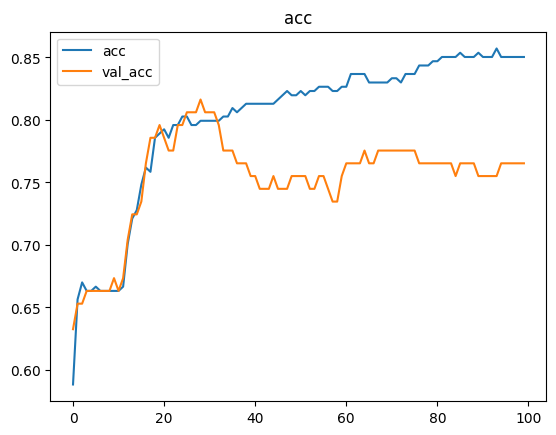

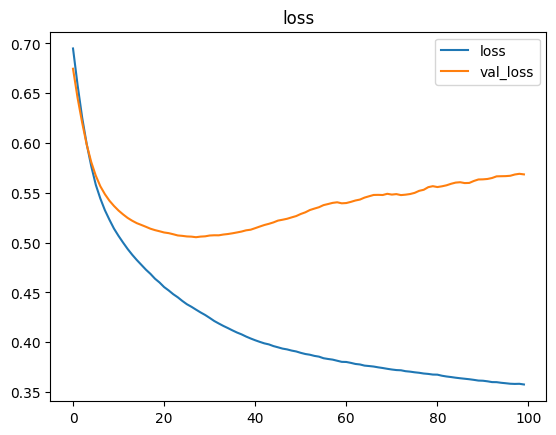

In [14]:
# See how your model is doing
plot_history(history)

Training Evaluation:

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

 No Diabetes       0.88      0.90      0.89       196
    Diabetes       0.79      0.76      0.77        98

    accuracy                           0.85       294
   macro avg       0.83      0.83      0.83       294
weighted avg       0.85      0.85      0.85       294



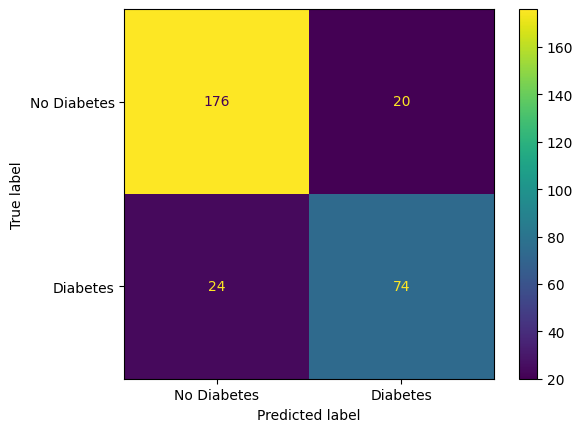

Testing Evaluation:

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
              precision    recall  f1-score   support

 No Diabetes       0.84      0.80      0.82        66
    Diabetes       0.63      0.69      0.66        32

    accuracy                           0.77        98
   macro avg       0.73      0.75      0.74        98
weighted avg       0.77      0.77      0.77        98



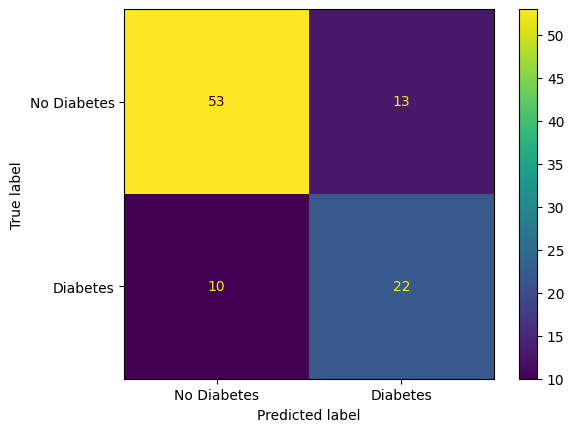

,Accuracy,Precision,Recall,F1 Score
class_model1 train,0.850340,0.787234,0.755102,0.770833
class_model1 test,0.765306,0.628571,0.687500,0.656716


In [15]:
# Make predicitons and evaluate your model
# Define labels for the confusion matrix
labels = ['No Diabetes', 'Diabetes']

# Evaluate training set
print('Training Evaluation:\n')
train_scores = eval_classification(class_model1, 
                             X_train, y_train, 
                             name='class_model1 train', 
                             labels=labels)
print('Testing Evaluation:\n')
# Confusion Matrix
test_scores = (eval_classification(class_model1, 
                                           X_test, y_test, 
                                           name='class_model1 test', 
                                           labels=labels))

scores = pd.concat([train_scores, test_scores])
scores